# **APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO**

Este notebook tem por objetivo demonstrar o treinamento e a avaliação de um algoritmo de Machine Learning de classificação.

Os dados são gerados artificialmente com `sklearn.datasets.make_moons`, que cria duas classes em formato de "lua" entrelaçadas — de propósito, NÃO separáveis por uma única reta. Isso deixa visualmente clara a diferença entre as fronteiras de decisão de cada família de classificador:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

# **PRÉ-PROCESSAMENTO**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Dataset sintetico: duas classes em forma de "lua", que NAO podem ser
# separadas por uma unica reta - de proposito, para expor a diferenca
# entre fronteiras lineares e nao lineares.
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['classe'] = y
df.head()

,x1,x2,classe
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


In [4]:
df.shape

(300, 3)

In [5]:
df['classe'].value_counts()

classe
1    150
0    150
Name: count, dtype: int64

## **Separação em treino/teste e escalonamento**

In [6]:
# Separando os dados em treino (70%) e teste (30%)
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=0
)

# Escalonamento ajustado (fit) SOMENTE no treino; o teste só passa por transform
scaler = StandardScaler()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)

In [7]:
x_treino.shape

(210, 2)

In [8]:
x_teste.shape

(90, 2)

In [9]:
y_treino.shape

(210,)

In [10]:
y_teste.shape

(90,)

# **NAIVE BAYES**

https://scikit-learn.org/stable/modules/naive_bayes.html

Treinamento do algoritmo

In [11]:
from sklearn.naive_bayes import GaussianNB

In [12]:
naive = GaussianNB()
naive.fit(x_treino, y_treino)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[111., 99.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.53,0.47]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[-0.55, 0.65], [ 0.61,-0.73]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[0.62,0.51], [0.72,0.54]]"


Avaliação do algoritmo

In [13]:
previsoes_naive = naive.predict(x_teste)
previsoes_naive

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0])

In [14]:
y_teste

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0])

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
accuracy_score(y_teste, previsoes_naive)

0.8666666666666667

In [17]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_naive) * 100.0))

Acurácia: 86.67%


In [18]:
confusion_matrix(y_teste, previsoes_naive)

array([[34,  5],
       [ 7, 44]])

In [19]:
print(classification_report(y_teste, previsoes_naive))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85        39
           1       0.90      0.86      0.88        51

    accuracy                           0.87        90
   macro avg       0.86      0.87      0.86        90
weighted avg       0.87      0.87      0.87        90



**Análise dados de treino**

In [20]:
previsoes_treino = naive.predict(x_treino)
previsoes_treino

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [21]:
accuracy_score(y_treino, previsoes_treino)

0.8571428571428571

In [22]:
confusion_matrix(y_treino, previsoes_treino)

array([[96, 15],
       [15, 84]])

### **Validação Cruzada**

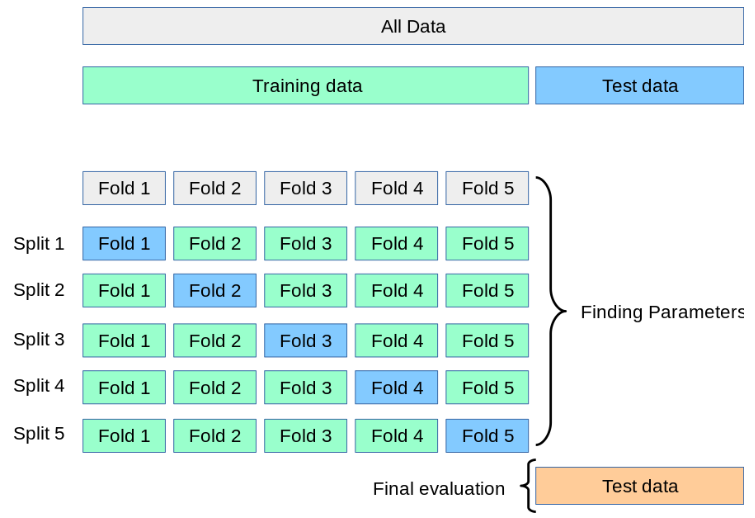

In [23]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.naive_bayes import GaussianNB

In [24]:
# Configuração de folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [25]:
# Criação do modelo
modelo = GaussianNB()

In [26]:
# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)

In [27]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Acurácia de Treino (Média): 0.8588994974874371
Acurácia de Validação (Média): 0.8581818181818182


Naive Bayes = 85,82% (validação cruzada), 85,71% (treino) e 86,67% (teste) - 78 acertos



### **Fronteira de decisão**

Região azul = pontos que o modelo classificaria como classe 0; região vermelha = classe 1. Os pontos são os dados de teste, coloridos pela classe REAL — pontos numa região da cor errada são os erros do modelo.

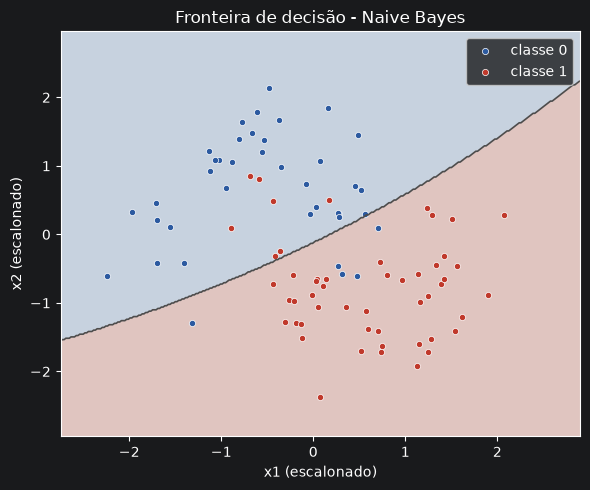

In [28]:
import matplotlib.pyplot as plt

# Malha de pontos cobrindo toda a area dos dados (treino + teste), para
# colorir cada regiao conforme a classe que o modelo preveria ali
X_plot = np.vstack([x_treino, x_teste])
xx, yy = np.meshgrid(
    np.linspace(X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5, 300),
    np.linspace(X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = naive.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#dbe7f6", "#f7d9d3"], alpha=0.9)
ax.contour(xx, yy, Z, levels=[0.5], colors="#4c4c4c", linewidths=1.2)

cores_pontos = ["#2c5aa0", "#c0392b"]
for classe, cor in zip([0, 1], cores_pontos):
    pts = x_teste[y_teste == classe]
    ax.scatter(pts[:, 0], pts[:, 1], c=cor, s=20, edgecolors="white",
               linewidths=0.5, label=f"classe {classe}")

ax.set_title("Fronteira de decisão - Naive Bayes")
ax.set_xlabel("x1 (escalonado)")
ax.set_ylabel("x2 (escalonado)")
ax.legend()
fig.tight_layout()
plt.show()